### Approach 1: Pixel-level RGB Classification

In this approach, each pixel in the image is treated as an independent sample.
The feature vector consists only of raw color values (R, G, B), without any spatial
or contextual information.

The classifier predicts whether a pixel belongs to the floor class based solely
on its color. Since no neighborhood, texture, or position information is used,
this approach serves as a simple baseline.

**Feature Vector:** (R, G, B)  
**Sample Unit:** Pixel  
**Strengths:** Simple, fast baseline  
**Limitations:** Highly sensitive to lighting, ignores spatial structure and texture  
**Expected Behavior:** Noisy predictions and limited generalization

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from pycocotools.coco import COCO
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# IMAGE_DIR = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train"
# COCO_JSON = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train/_annotations.coco.json"
IMAGE_DIR = "/content/drive/MyDrive/230077_vivekananda"
COCO_JSON = "/content/drive/MyDrive/230077_vivekananda/vivekananda.json"

coco = COCO(COCO_JSON)

print(f"Total images: {len(coco.imgs)}")
print(f"Total annotations: {len(coco.getAnnIds())}")

# Floor category IDs (adjust if needed)
FLOOR_CAT_IDS = [0, 1]

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Total images: 10
Total annotations: 10


In [3]:
img_ids = list(coco.imgs.keys())
print(f"Images to process: {len(img_ids)}")

Images to process: 10


In [4]:
X = []
y = []

PIXELS_PER_IMAGE = 200

print("Extracting pixel-level RGB samples...")

for i, img_id in enumerate(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGE_DIR, img_info["file_name"])
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w = img.shape[:2]

    # Build floor mask
    floor_mask = np.zeros((h, w), dtype=np.uint8)
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        if ann["category_id"] in FLOOR_CAT_IDS:
            floor_mask |= coco.annToMask(ann)

    # Sample random pixels
    for _ in range(PIXELS_PER_IMAGE):
        py = np.random.randint(0, h)
        px = np.random.randint(0, w)

        R, G, B = img[py, px]
        X.append([R, G, B])
        y.append(1 if floor_mask[py, px] else 0)

    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(img_ids)} images")

X = np.array(X)
y = np.array(y)

print(f"Total samples: {len(X)}")
print(f"Floor pixels: {np.sum(y == 1)}")
print(f"Non-floor pixels: {np.sum(y == 0)}")

Extracting pixel-level RGB samples...
Total samples: 2000
Floor pixels: 962
Non-floor pixels: 1038


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1600
Test size: 400


In [7]:
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    random_state=42
)

svm.fit(X_train, y_train)

SVC(C=10, random_state=42)

In [8]:
y_pred = svm.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Train Accuracy:", svm.score(X_train, y_train))
print("Test Accuracy:", svm.score(X_test, y_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.56      0.63       208
           1       0.62      0.78      0.69       192

    accuracy                           0.66       400
   macro avg       0.67      0.67      0.66       400
weighted avg       0.68      0.66      0.66       400

Train Accuracy: 0.73125
Test Accuracy: 0.6625


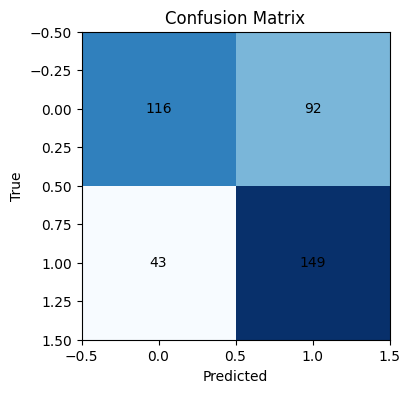

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [10]:
def predict_floor_pixelwise(img_path, svm, scaler):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    pixels = img.reshape(-1, 3)
    pixels_scaled = scaler.transform(pixels)

    preds = svm.predict(pixels_scaled)
    mask = preds.reshape(h, w)

    return img, mask

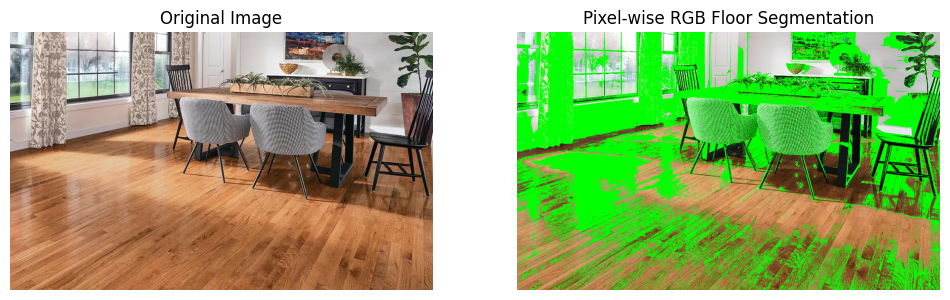

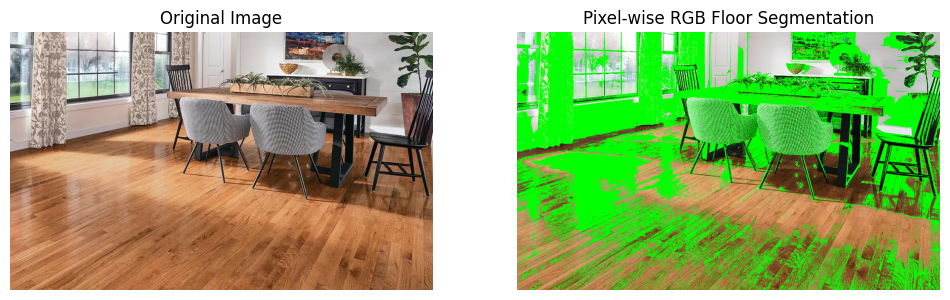

In [13]:
test_img_path = "/content/floor-1.avif"  # replace with your image

img, mask = predict_floor_pixelwise(test_img_path, svm, scaler)

overlay = img.copy()
overlay[mask == 1] = [0, 255, 0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Pixel-wise RGB Floor Segmentation")
plt.axis("off")

plt.show()


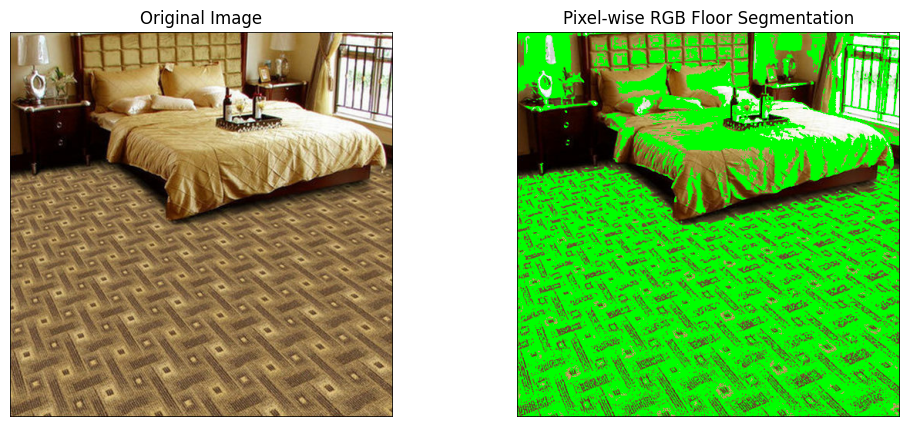

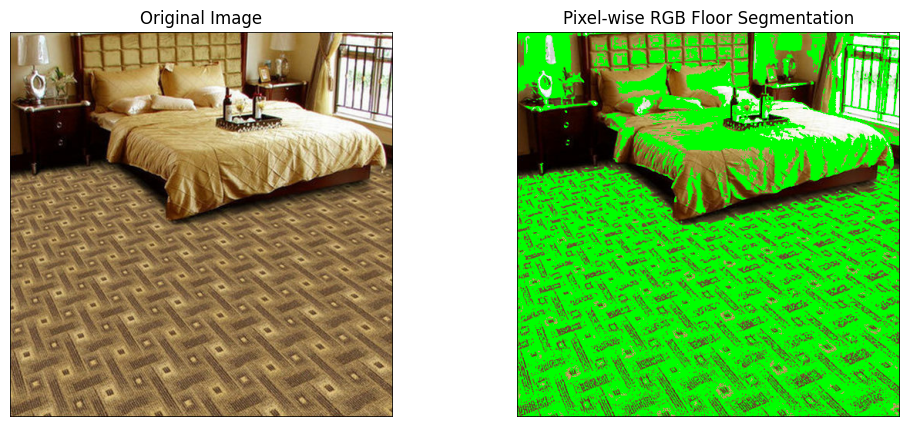

In [14]:
test_img_path = "/content/floor-10.jpg"  # replace with your image

img, mask = predict_floor_pixelwise(test_img_path, svm, scaler)

overlay = img.copy()
overlay[mask == 1] = [0, 255, 0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Pixel-wise RGB Floor Segmentation")
plt.axis("off")

plt.show()